In [1]:
import sys
sys.path.append("..")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from src.features import FEATURE_COLUMNS
from src.clustering import k_distance_plot_data, fit_dbscan

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (9, 5)

In [2]:
# df: raw-unit features + Cluster/Persona from notebook 04, used for display.
# X_log: log-transformed features the scaler was fit on — DBSCAN runs on X_scaled.
df = pd.read_csv("../data/processed/customer_features_clustered.csv")
X_log = pd.read_csv("../data/processed/customer_features_log.csv")
scaler = joblib.load("../models/scaler.joblib")

X_scaled = scaler.transform(X_log[FEATURE_COLUMNS])
print(f"Customers: {len(df):,}")

Customers: 4,327


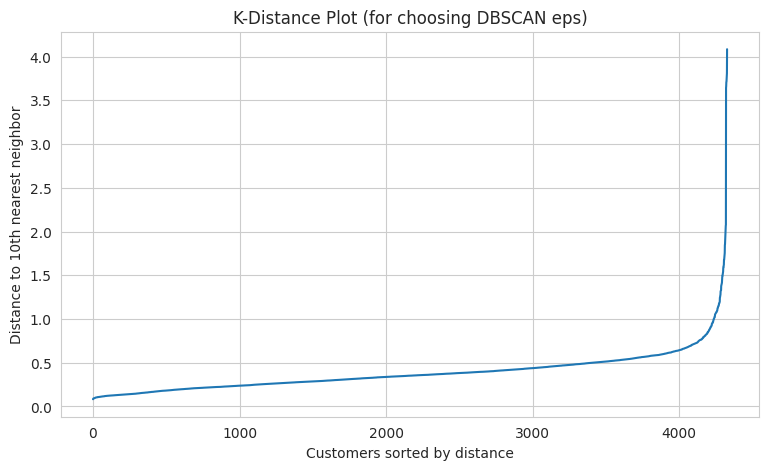

Try eps values around where the curve visibly bends upward.


In [3]:
min_samples = 10  # a bit higher than the K-Means default given our larger N
k_distances = k_distance_plot_data(X_scaled, min_samples=min_samples)

plt.plot(k_distances)
plt.xlabel("Customers sorted by distance")
plt.ylabel(f"Distance to {min_samples}th nearest neighbor")
plt.title("K-Distance Plot (for choosing DBSCAN eps)")
plt.savefig("../reports/figures/05_kdistance_plot.png", dpi=120)
plt.show()

print("Try eps values around where the curve visibly bends upward.")

In [4]:
eps = 1.3           # <-- tune this based on the k-distance plot
min_samples = 10    # <-- and this: higher = stricter about what counts as "dense"

dbscan_model, dbscan_labels = fit_dbscan(X_scaled, eps=eps, min_samples=min_samples)
df["Cluster_DBSCAN"] = dbscan_labels

n_clusters = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise = list(dbscan_labels).count(-1)

print(f"Dense clusters found: {n_clusters}")
print(f"Noise points (potential anomalies): {n_noise:,} ({n_noise/len(df):.1%} of customers)")

Dense clusters found: 4
Noise points (potential anomalies): 22 (0.5% of customers)


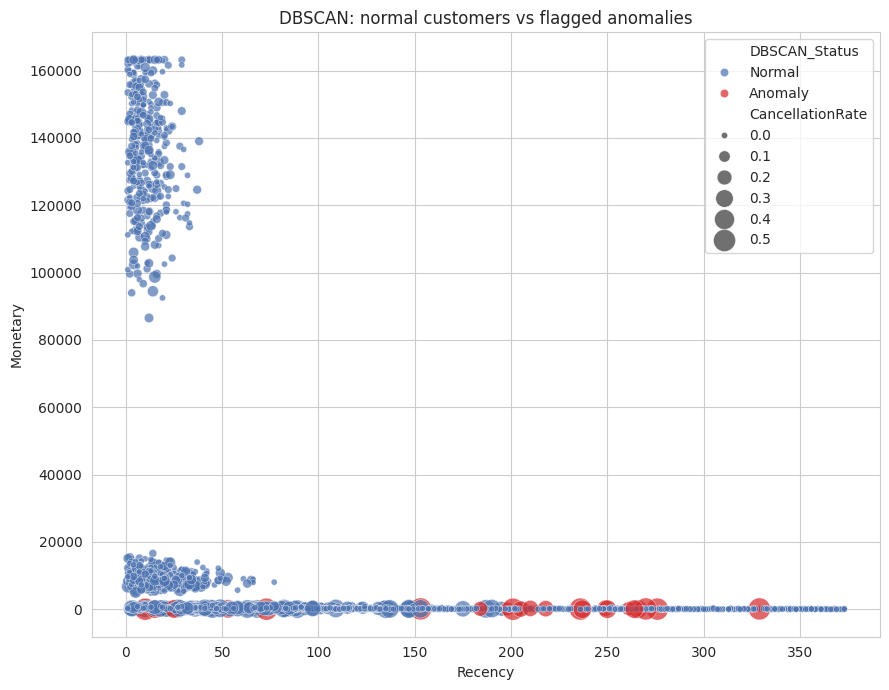

In [5]:
plt.figure(figsize=(9, 7))
df["DBSCAN_Status"] = np.where(df["Cluster_DBSCAN"] == -1, "Anomaly", "Normal")
sns.scatterplot(
    data=df, x="Recency", y="Monetary",
    hue="DBSCAN_Status", palette={"Normal": "#4C72B0", "Anomaly": "#D62728"},
    size="CancellationRate", sizes=(20, 250), alpha=0.7
)
plt.title("DBSCAN: normal customers vs flagged anomalies")
plt.tight_layout()
plt.savefig("../reports/figures/05_dbscan_anomalies.png", dpi=120)
plt.show()

In [6]:
comparison = df.groupby("DBSCAN_Status")[FEATURE_COLUMNS].mean().round(1)
comparison

,Recency,Frequency,Monetary,AvgBasketValue,AvgItemsPerBasket,UniqueProducts,CancellationRate,CustomerLifespanDays
DBSCAN_Status,,,,,,,,
Anomaly,190.1,2.2,94.3,45.8,13.6,4.4,0.4,65.8
Normal,67.9,12.3,14194.2,363.1,95.7,17.7,0.0,213.4


In [7]:
anomalies_df = df[df["Cluster_DBSCAN"] == -1][
    ["CustomerID"] + FEATURE_COLUMNS
].sort_values("Monetary", ascending=False)

print(f"{len(anomalies_df):,} customers flagged as anomalies. Top 15 by spend:")
anomalies_df.head(15)

22 customers flagged as anomalies. Top 15 by spend:


,CustomerID,Recency,Frequency,Monetary,AvgBasketValue,AvgItemsPerBasket,UniqueProducts,CancellationRate,CustomerLifespanDays
427,12778,249,3.0,339.07,113.023333,26.333333,9,0.250000,67
4173,16564,210,3.0,257.36,85.786667,19.333333,8,0.250000,89
2029,14398,261,5.0,186.92,37.384000,12.800000,10,0.166667,87
3708,16089,218,3.0,183.73,61.243333,8.666667,6,0.250000,147
22,12368,53,2.0,117.54,58.770000,11.000000,2,0.333333,30
4129,16520,184,4.0,117.14,29.285000,10.750000,8,0.200000,31
952,13310,153,1.0,105.59,105.590000,20.000000,3,0.500000,0
1260,13621,329,1.0,99.69,99.690000,34.000000,4,0.500000,0
1338,13701,270,1.0,90.47,90.470000,20.000000,3,0.500000,0
4043,16431,25,2.0,81.72,40.860000,13.500000,4,0.333333,20


In [8]:
df.to_csv("../data/processed/customer_features_clustered.csv", index=False)
joblib.dump(dbscan_model, "../models/dbscan_model.joblib")
print("Updated processed data and saved dbscan_model.joblib")

Updated processed data and saved dbscan_model.joblib
